In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [2]:
df = pd.read_csv(r"C:\Users\monika\OneDrive\Desktop\UberDataset.csv")
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   str    
 1   END_DATE    1155 non-null   str    
 2   CATEGORY    1155 non-null   str    
 3   START       1155 non-null   str    
 4   STOP        1155 non-null   str    
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    str    
dtypes: float64(1), str(6)
memory usage: 63.3 KB


In [4]:
df.shape

(1156, 7)

In [5]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='str')

In [6]:
df.describe(include="all")

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
count,1156,1155,1155,1155,1155,1156.000000,653
unique,1155,1154,2,177,188,NaN,10
top,6/28/2016 23:34,6/28/2016 23:59,Business,Cary,Cary,NaN,Meeting
freq,2,2,1078,201,203,NaN,187
mean,NaN,NaN,NaN,NaN,NaN,21.115398,NaN
std,NaN,NaN,NaN,NaN,NaN,359.299007,NaN
min,NaN,NaN,NaN,NaN,NaN,0.500000,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.900000,NaN
50%,NaN,NaN,NaN,NaN,NaN,6.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,10.400000,NaN


In [7]:
df.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df = df.drop_duplicates()

In [10]:
df["PURPOSE"] = df["PURPOSE"].fillna("Unknown")

In [11]:
df["START_DATE"] = pd.to_datetime(df["START_DATE"], errors="coerce")
df["END_DATE"] = pd.to_datetime(df["END_DATE"], errors="coerce")

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 1155 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  421 non-null    datetime64[us]
 1   END_DATE    420 non-null    datetime64[us]
 2   CATEGORY    1154 non-null   str           
 3   START       1154 non-null   str           
 4   STOP        1154 non-null   str           
 5   MILES       1155 non-null   float64       
 6   PURPOSE     1155 non-null   str           
dtypes: datetime64[us](2), float64(1), str(4)
memory usage: 72.2 KB


In [13]:
df = df.dropna(subset=["START_DATE","END_DATE"])

In [14]:
df["Year"] = df["START_DATE"].dt.year

In [15]:
df["Month"] = df["START_DATE"].dt.month_name()

In [16]:
df["Day"] = df["START_DATE"].dt.day_name()

In [17]:
df["Hour"] = df["START_DATE"].dt.hour

In [18]:
df["Trip_Duration"] = (df["END_DATE"] - df["START_DATE"]).dt.total_seconds()/60

In [19]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Year,Month,Day,Hour,Trip_Duration
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016,January,Friday,21,6.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016,January,Saturday,1,12.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016,January,Saturday,20,13.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016,January,Tuesday,17,14.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016,January,Wednesday,14,67.0


In [20]:
print("Total Trips :", len(df))

Total Trips : 420


In [21]:
print("Total Miles :", df["MILES"].sum())

Total Miles : 3815.2


In [22]:
print("Average Miles :", df["MILES"].mean())

Average Miles : 9.083809523809524


In [23]:
df.loc[df["MILES"].idxmax()]

START_DATE       2016-04-02 19:38:00
END_DATE         2016-04-02 22:36:00
CATEGORY                    Business
START                   Jacksonville
STOP                       Ridgeland
MILES                          174.2
PURPOSE               Customer Visit
Year                            2016
Month                          April
Day                         Saturday
Hour                              19
Trip_Duration                  178.0
Name: 297, dtype: object

In [24]:
df.loc[df["MILES"].idxmin()]

START_DATE       2016-06-08 17:16:00
END_DATE         2016-06-08 17:18:00
CATEGORY                    Business
START                           Soho
STOP                         Tribeca
MILES                            0.5
PURPOSE              Errand/Supplies
Year                            2016
Month                           June
Day                        Wednesday
Hour                              17
Trip_Duration                    2.0
Name: 420, dtype: object

In [25]:
df["CATEGORY"].value_counts()

CATEGORY
Business    407
Personal     13
Name: count, dtype: int64

In [26]:
df["PURPOSE"].value_counts()

PURPOSE
Unknown            159
Meeting             81
Meal/Entertain      64
Errand/Supplies     47
Customer Visit      46
Temporary Site      14
Between Offices      9
Name: count, dtype: int64

In [27]:
df["Month"].value_counts()

Month
November     63
August       43
March        42
June         42
February     40
July         40
December     39
May          26
April        25
October      24
January      23
September    13
Name: count, dtype: int64

In [28]:
df["Day"].value_counts()

Day
Friday       87
Monday       62
Thursday     61
Tuesday      60
Saturday     52
Wednesday    50
Sunday       48
Name: count, dtype: int64

In [29]:
df["Hour"].value_counts().sort_index()

Hour
0      7
1      2
2      1
3      2
5      1
6      2
7      2
8     13
9     20
10    20
11    17
12    28
13    37
14    32
15    28
16    34
17    35
18    40
19    28
20    26
21    22
22    12
23    11
Name: count, dtype: int64

In [30]:
df["START"].value_counts().head(10)

START
Cary                95
Morrisville         38
Whitebridge         34
Unknown Location    22
Durham              20
Raleigh             11
Apex                 8
Westpark Place       8
Berkeley             7
Kissimmee            6
Name: count, dtype: int64

In [31]:
df["STOP"].value_counts().head(10)

STOP
Cary                95
Morrisville         41
Whitebridge         29
Unknown Location    21
Durham              19
Raleigh             11
Apex                 8
Berkeley             8
Edgehill Farms       7
Westpark Place       7
Name: count, dtype: int64

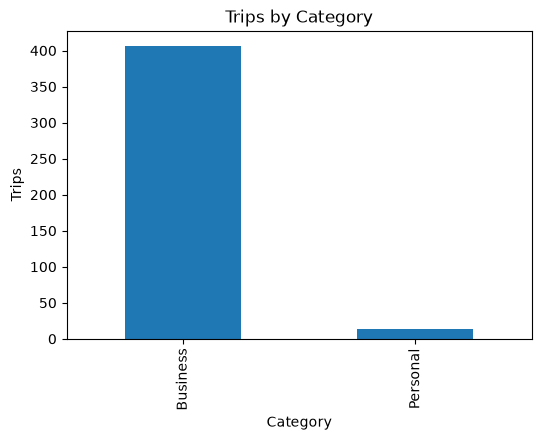

In [32]:
df["CATEGORY"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Trips by Category")
plt.xlabel("Category")
plt.ylabel("Trips")
plt.show()

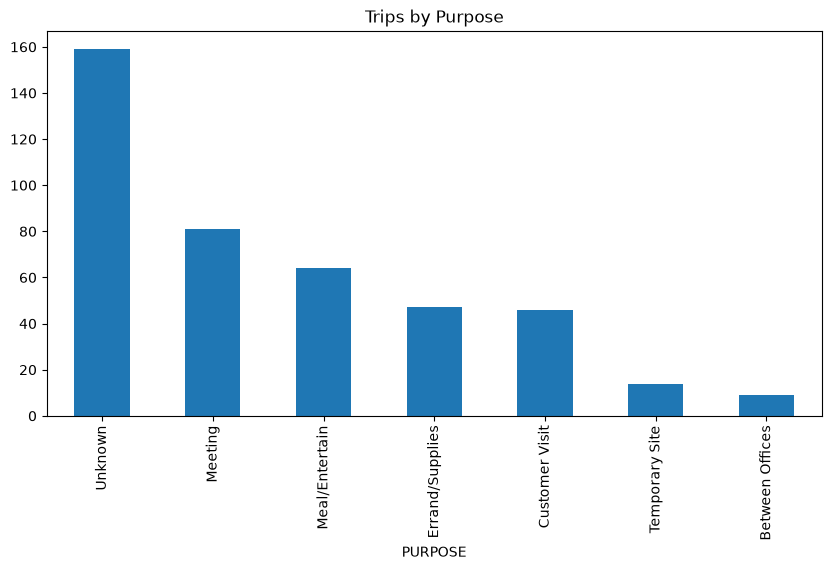

In [33]:
df["PURPOSE"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Trips by Purpose")
plt.show()

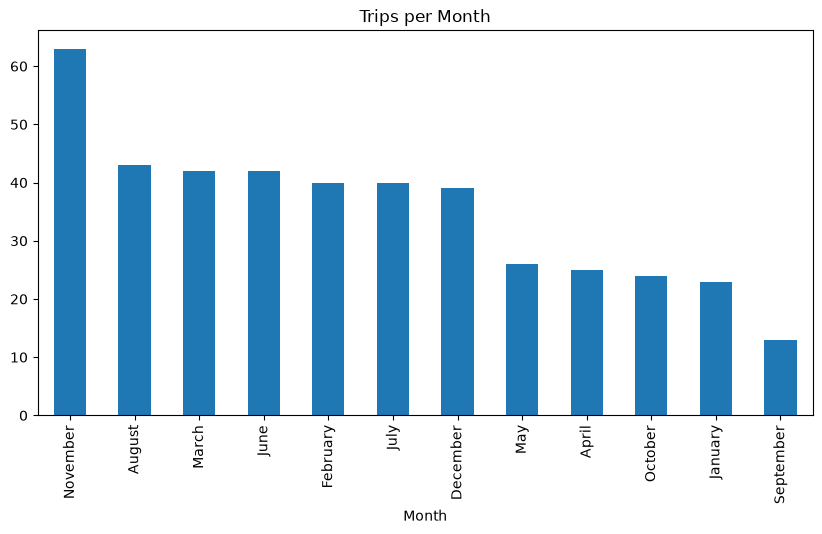

In [34]:
df["Month"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Trips per Month")
plt.show()

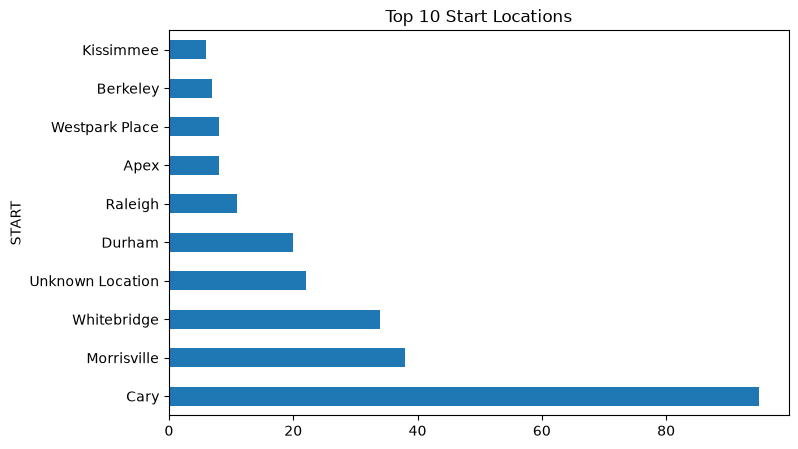

In [35]:
df["START"].value_counts().head(10).plot(kind="barh", figsize=(8,5))
plt.title("Top 10 Start Locations")
plt.show()

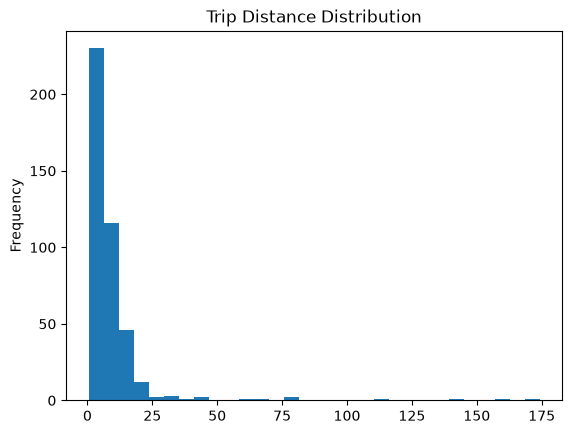

In [36]:
df["MILES"].plot(kind="hist", bins=30)
plt.title("Trip Distance Distribution")
plt.show()

In [39]:
df.to_csv(r"C:\Users\monika\OneDrive\Desktop\Uber_Cleaned.csv", index=False)